In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_data

data = load_data("../data/nifty50_processed.csv")

# Drop NaNs
data = data.dropna()

data.head()

,Close,High,Low,Open,Volume,returns,volatility
Date,,,,,,,
2015-02-03,8756.549805,8837.299805,8726.650391,8823.150391,208700,-0.004654,0.011485
2015-02-04,8723.700195,8792.849609,8704.400391,8789.150391,195300,-0.003758,0.011521
2015-02-05,8711.700195,8838.450195,8683.650391,8733.099609,173600,-0.001377,0.008886
2015-02-06,8661.049805,8726.200195,8645.549805,8696.849609,171300,-0.005831,0.009004
2015-02-09,8526.349609,8605.549805,8516.349609,8584.400391,146800,-0.015675,0.009376


In [2]:
data['returns_scaled'] = data['returns'] * 100


In [8]:
from arch import arch_model

garch = arch_model(data['returns_scaled'], vol='Garch', p=1, q=1)

garch_fit = garch.fit()

print(garch_fit.summary())

params = garch_fit.params
alpha = params['alpha[1]']
beta = params['beta[1]']

print("Alpha:", alpha)
print("Beta:", beta)
print("Alpha + Beta:", alpha + beta)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1417097.270063139
Iteration:      2,   Func. Count:     15,   Neg. LLF: 23732972661.318016
Iteration:      3,   Func. Count:     23,   Neg. LLF: 3497.108902826886
Iteration:      4,   Func. Count:     31,   Neg. LLF: 4127.868714081398
Iteration:      5,   Func. Count:     38,   Neg. LLF: 3160.600141169605
Iteration:      6,   Func. Count:     43,   Neg. LLF: 3160.595298136057
Iteration:      7,   Func. Count:     48,   Neg. LLF: 3160.594538912562
Iteration:      8,   Func. Count:     53,   Neg. LLF: 3160.5945329844735
Iteration:      9,   Func. Count:     57,   Neg. LLF: 3160.5945329864066
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3160.5945329844735
            Iterations: 9
            Function evaluations: 57
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:         returns_scaled   R-squared:            

In [9]:
data['garch_vol'] = garch_fit.conditional_volatility

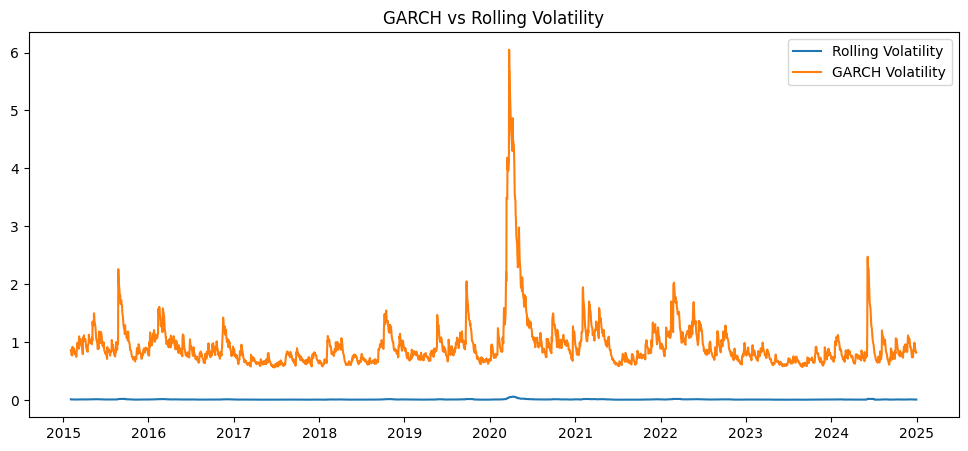

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(data['volatility'], label='Rolling Volatility')
plt.plot(data['garch_vol'], label='GARCH Volatility')
plt.legend()
plt.title("GARCH vs Rolling Volatility")
plt.show()

In [11]:
data['volatility_scaled'] = data['volatility'] * 100

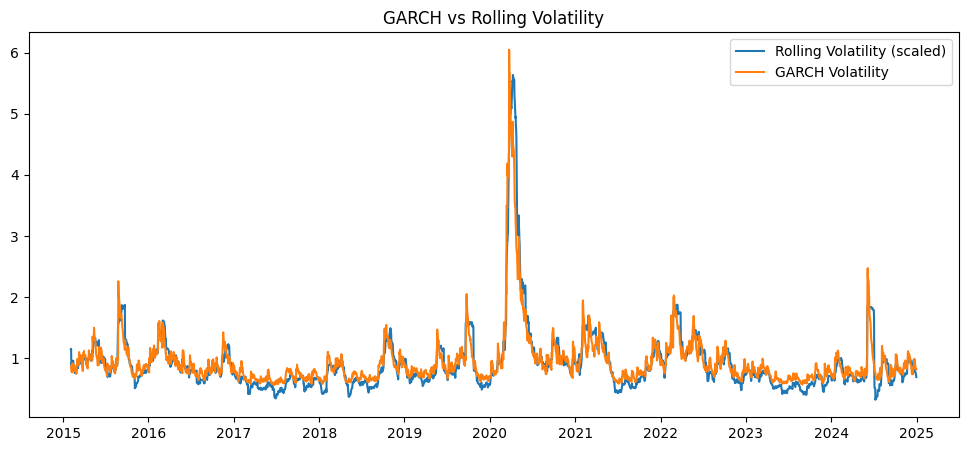

In [12]:
plt.figure(figsize=(12,5))
plt.plot(data['volatility_scaled'], label='Rolling Volatility (scaled)')
plt.plot(data['garch_vol'], label='GARCH Volatility')
plt.legend()
plt.title("GARCH vs Rolling Volatility")
plt.show()

In [13]:
data.to_csv("../data/nifty50_with_garch.csv")

In [14]:
data[['returns', 'garch_vol']].to_csv("../results/garch_results.csv")